# 02 · Isolation Forest — Unsupervised Baseline

A fast CPU baseline before the LSTM. It answers a useful question:
**how far can we get without any attack labels at all?**

Isolation Forest trains on **normal data only**. It builds random trees and
measures how quickly each sample gets isolated — outliers separate in fewer
splits, so a short average path means *anomaly*.

Why this matters for the project: in the real world you have plenty of normal
traffic and almost no labelled attacks. This model needs only the former.

In [1]:
# ── Project paths (edit ADFA_ROOT if your dataset lives elsewhere) ────────────
import os, sys, glob, json, warnings
warnings.filterwarnings("ignore")

PROJECT   = "/home/sudipto-roy-s-hawon/Downloads/Project"
ADFA_ROOT = "/home/sudipto-roy-s-hawon/Downloads/ADFA-LD"
MODEL_DIR = os.path.join(PROJECT, "ml", "saved_model")
os.makedirs(MODEL_DIR, exist_ok=True)

# make `import live_predictor` work from inside ml/
sys.path.insert(0, os.path.join(PROJECT, "ml"))

assert os.path.isdir(ADFA_ROOT), f"ADFA-LD not found at {ADFA_ROOT}"
print("Project  :", PROJECT)
print("Dataset  :", ADFA_ROOT)
print("Models   :", MODEL_DIR)

Project  : /home/sudipto-roy-s-hawon/Downloads/Project
Dataset  : /home/sudipto-roy-s-hawon/Downloads/ADFA-LD
Models   : /home/sudipto-roy-s-hawon/Downloads/Project/ml/saved_model


## 1 · Config

In [2]:
MAX_SYSCALL   = 350    # ADFA-LD syscall numbers stay under 350
TOP_BIGRAMS   = 100    # how many syscall pairs to keep as features
CONTAMINATION = 0.05   # assumed share of anomalies inside the normal set

print(f"feature vector = {MAX_SYSCALL} unigrams + {TOP_BIGRAMS} bigrams "
      f"= {MAX_SYSCALL + TOP_BIGRAMS} dimensions")

feature vector = 350 unigrams + 100 bigrams = 450 dimensions


## 2 · Load traces

In [3]:
def read_trace(p):
    with open(p) as f:
        return [int(x) for x in f.read().split() if x.isdigit()]

normal = [t for t in (read_trace(f)
          for f in glob.glob(f"{ADFA_ROOT}/Training_Data_Master/*.txt")) if len(t) > 10]

attack, attack_family = [], []
for f in glob.glob(f"{ADFA_ROOT}/Attack_Data_Master/*/*.txt"):
    t = read_trace(f)
    if len(t) > 10:
        attack.append(t)
        attack_family.append(os.path.basename(os.path.dirname(f)).split("_")[0])

print(f"normal: {len(normal)}   attack: {len(attack)}")

normal: 833   attack: 746


## 3 · Feature extraction

A model needs a fixed-length vector, but traces vary from 20 to 10 000 syscalls.
Two complementary views:

**Unigram** — *how often* each syscall appears. Captures behaviour:
a process reading 500 files looks different from one that reads 3.

**Bigram** — *which pairs* occur consecutively. Captures order:
`open→read→close` is ordinary; `open→open→open` is a directory sweep.
Unigrams alone cannot tell those apart.

Both are normalised to relative frequency so long and short traces compare fairly.

In [4]:
from collections import Counter
import numpy as np

# rank bigrams across the whole corpus, keep the TOP_BIGRAMS most frequent
bg_counter = Counter()
for t in normal + attack:
    for i in range(len(t) - 1):
        if t[i] < MAX_SYSCALL and t[i+1] < MAX_SYSCALL:
            bg_counter[(t[i], t[i+1])] += 1

top_bigrams  = [bg for bg, _ in bg_counter.most_common(TOP_BIGRAMS)]
bigram_index = {bg: i for i, bg in enumerate(top_bigrams)}

print("most frequent syscall pairs:")
for bg, c in bg_counter.most_common(8):
    print(f"  {str(bg):<12} {c:>8,}")

most frequent syscall pairs:
  (3, 3)         42,985
  (168, 168)     37,697
  (168, 265)     24,527
  (4, 4)         23,837
  (265, 168)     23,374
  (265, 265)     19,589
  (240, 240)     15,283
  (78, 78)       15,092


In [5]:
def featurize(syscalls):
    """syscall list -> fixed-length vector (unigram freq ++ bigram freq)."""
    uni = np.zeros(MAX_SYSCALL, dtype=np.float32)
    for sc in syscalls:
        if 0 <= sc < MAX_SYSCALL:
            uni[sc] += 1
    if uni.sum():
        uni /= uni.sum()

    bi = np.zeros(TOP_BIGRAMS, dtype=np.float32)
    for i in range(len(syscalls) - 1):
        j = bigram_index.get((syscalls[i], syscalls[i+1]))
        if j is not None:
            bi[j] += 1
    if bi.sum():
        bi /= bi.sum()

    return np.concatenate([uni, bi])

X_normal = np.array([featurize(t) for t in normal])
X_attack = np.array([featurize(t) for t in attack])
print(f"X_normal {X_normal.shape}    X_attack {X_attack.shape}")

X_normal (833, 450)    X_attack (746, 450)


## 4 · Scale, then train

`StandardScaler` is fit on **normal data only** — the attack set must stay
completely unseen, or we would be leaking test information into training.

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

scaler = StandardScaler().fit(X_normal)      # fit: normal only
Xn = scaler.transform(X_normal)
Xa = scaler.transform(X_attack)              # transform with the same scaler

model = IsolationForest(
    n_estimators=200,
    contamination=CONTAMINATION,
    random_state=42,
    n_jobs=-1,
).fit(Xn)                                    # fit: normal only

print("trained on normal data only — attack traces never seen")

trained on normal data only — attack traces never seen


## 5 · Evaluate

Prediction is `1` for normal, `-1` for anomaly.

In [7]:
pred_n, pred_a = model.predict(Xn), model.predict(Xa)
score_n, score_a = model.score_samples(Xn), model.score_samples(Xa)

tn = (pred_n ==  1).sum()   # normal kept as normal
td = (pred_a == -1).sum()   # attack caught

print(f"normal kept as normal : {tn}/{len(pred_n)}  ({100*tn/len(pred_n):.1f}%)")
print(f"attack caught         : {td}/{len(pred_a)}  ({100*td/len(pred_a):.1f}%)")
print(f"\nmean anomaly score  normal {score_n.mean():+.4f}   attack {score_a.mean():+.4f}")
print(f"separation          {score_n.mean() - score_a.mean():+.4f}   (higher = better)")

normal kept as normal : 791/833  (95.0%)
attack caught         : 136/746  (18.2%)

mean anomaly score  normal -0.3433   attack -0.3556
separation          +0.0123   (higher = better)


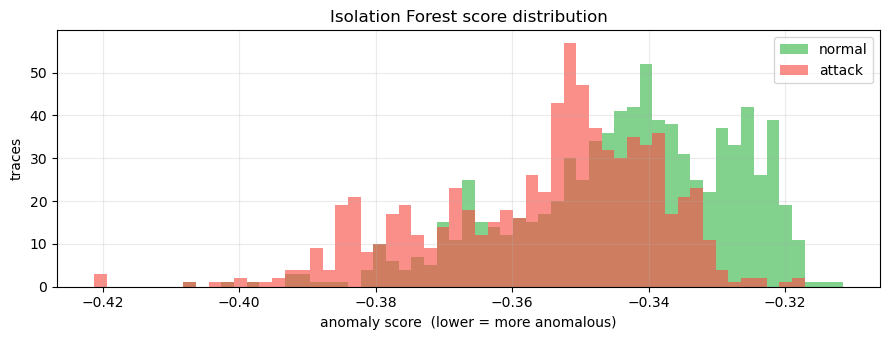

In [8]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 3.5))
bins = np.linspace(min(score_n.min(), score_a.min()),
                   max(score_n.max(), score_a.max()), 60)
ax.hist(score_n, bins=bins, alpha=.65, label="normal", color="#3fb950")
ax.hist(score_a, bins=bins, alpha=.65, label="attack", color="#f85149")
ax.set_xlabel("anomaly score  (lower = more anomalous)")
ax.set_ylabel("traces"); ax.set_title("Isolation Forest score distribution")
ax.legend(); ax.grid(alpha=.25); plt.tight_layout(); plt.show()

### Detection rate per attack family

In [9]:
print(f"{'family':<20}{'rate':>7}")
print("-" * 50)
for fam in sorted(set(attack_family)):
    idx = [i for i, f in enumerate(attack_family) if f == fam]
    if not idx:
        continue
    rate = 100 * sum(pred_a[i] == -1 for i in idx) / len(idx)
    bar = "#" * int(rate / 4)
    print(f"{fam:<20}{rate:>6.0f}%  {bar}")

family                 rate
--------------------------------------------------
Adduser                 11%  ##
Hydra                   18%  ####
Java                     8%  ##
Meterpreter             23%  #####
Web                     31%  #######


### Reading the result

Detection is modest — Isolation Forest sees a trace as a **bag of frequencies**
and mostly loses the *order* of events. Bigrams recover a little of that, but
an attack that uses ordinary syscalls in an unusual sequence still slips past.

That limitation is precisely the argument for the LSTM in notebook 03: it reads
the sequence in order and carries state between steps.

The baseline still earns its place — it trains in seconds on CPU, needs no
attack labels, and gives the LSTM a number to beat.

## 6 · Save

In [ ]:
import joblib

joblib.dump(model,       f"{MODEL_DIR}/isolation_forest.pkl")
joblib.dump(scaler,      f"{MODEL_DIR}/scaler.pkl")
joblib.dump(top_bigrams, f"{MODEL_DIR}/top_bigrams.pkl")

json.dump({
    "max_syscall":   MAX_SYSCALL,
    "top_bigrams":   TOP_BIGRAMS,
    "feature_size":  int(X_normal.shape[1]),
    "contamination": CONTAMINATION,
    "threshold":     float(np.percentile(score_n, 5)),
}, open(f"{MODEL_DIR}/config.json", "w"), indent=2)

for f in ["isolation_forest.pkl", "scaler.pkl", "top_bigrams.pkl", "config.json"]:
    print(f"  saved {f:<24} {os.path.getsize(f'{MODEL_DIR}/{f}'):>9,} bytes")

  saved isolation_forest.pkl     1,737,145 bytes
  saved scaler.pkl                  11,383 bytes
  saved top_bigrams.pkl                632 bytes
  saved config.json                    131 bytes


: 

---
| | Isolation Forest |
|---|---|
| Supervision | none — normal data only |
| Features | 450-dim frequency vector |
| Sees order? | barely (bigrams only) |
| Trains in | seconds, CPU |

**Next:** `03_lstm_train.ipynb` — read the sequence properly, on the GPU.